In [48]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os

In [ ]:
! pip install langchain_huggingface

In [ ]:
load_dotenv()  # Load environment variables from .env file

In [51]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [55]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

# Logic to create an outline based on the title
def create_outline(state: BlogState) -> BlogState:
    hf_endpoint = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-120b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )
    title = state['title']
    prompt = f"Create a detailed outline for a blog post titled in max 250 characters: '{title}'"
    llm = ChatHuggingFace(llm=hf_endpoint, max_output_tokens=512)
    outline = llm.invoke(prompt).content
    state['outline'] = outline
    return state

# Logic to create content based on the outline
def create_content(state: BlogState) -> BlogState:
    hf_endpoint = HuggingFaceEndpoint(
        repo_id="openai/gpt-oss-120b",
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )
    outline = state['outline']
    prompt = f"Write a detailed blog post based on the following outline: '{outline}'"
    llm = ChatHuggingFace(llm=hf_endpoint, max_output_tokens=8192)
    content = llm.invoke(prompt).content
    state['content'] = content
    return state

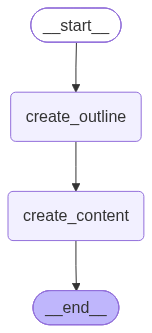

In [56]:
blog_graph = StateGraph(BlogState)

# add nodes to the graph
blog_graph.add_node("create_outline", create_outline)
blog_graph.add_node("create_content", create_content)

# add edges to the graph
blog_graph.add_edge(START, "create_outline")
blog_graph.add_edge("create_outline", "create_content")
blog_graph.add_edge("create_content", END)

blog_graph.compile()  # Visualize the graph

In [57]:
workflow = blog_graph.compile()

initial_state = BlogState(title="The Future of AI in Healthcare")
final_state = workflow.invoke(initial_state)

print(f"Detailed outline: {final_state['outline']}")
print(f"######################################################################################")
print(f"Detailed content: {final_state['content']}")

Detailed outline: **Blog Post Title (≤ 250 characters)**  
*The Future of AI in Healthcare: Transforming Patient Care, Clinical Decision‑Making, and Industry Innovation*

---

## Detailed Outline

| Section | Heading (H‑Level) | Key Points / Sub‑topics | Approx. Word Count |
|---------|-------------------|------------------------|--------------------|
| **1** | **Introduction** (H1) | • Hook: a striking statistic or anecdote (e.g., “A 2025 study predicts AI will cut hospital readmissions by 30%”) <br>• Brief definition of AI in the medical context (machine learning, NLP, computer vision, generative models) <br>• Why the future of AI matters now – regulatory push, data explosion, pandemic‑driven digital health acceleration <br>• Thesis statement: AI will reshape *four* core pillars of healthcare – diagnosis, treatment, operations, and patient empowerment. | 200‑250 |
| **2** | **Current Landscape** (H2) | **2.1** *Where AI Stands Today* <br>– Overview of mature applications (radiology i